 پروژه پایانی — تشخیص اخبار جعلی
## Fake News Detection
**درس:** مبانی داده‌کاوی | **استاد:** دکتر حسام عمران‌پور

**Upload Fake.csv and True.csv from Kaggle**

Download them from: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset

In [ ]:
from google.colab import files

print('Please upload Fake.csv and True.csv ...')
uploaded = files.upload()  # select BOTH files at once
print('Uploaded:', list(uploaded.keys()))

Please upload Fake.csv and True.csv ...


Saving Fake.csv to Fake.csv
Saving True.csv to True.csv
Uploaded: ['Fake.csv', 'True.csv']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, accuracy_score,
    f1_score, precision_score, recall_score
)
from sklearn.metrics import adjusted_rand_score

print('All libraries imported successfully!')

All libraries imported successfully!


In [ ]:
fake = pd.read_csv('Fake.csv')
true = pd.read_csv('True.csv')

fake['label'] = 1
true['label'] = 0

df = pd.concat([fake, true], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Total rows: {df.shape[0]:,} | Columns: {df.shape[1]}')
print('Columns:', df.columns.tolist())
df.head(3)

Total rows: 44,898 | Columns: 5
Columns: ['title', 'text', 'subject', 'date', 'label']


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",0


In [ ]:
print('=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Duplicates ===')
print(f'Found: {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)
print(f'After removal: {df.shape[0]:,} rows')

print('\n=== Class Distribution ===')
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True).round(3))

=== Missing Values ===
title      0
text       0
subject    0
date       0
label      0
dtype: int64

=== Duplicates ===
Found: 209
After removal: 44,689 rows

=== Class Distribution ===
label
1    23478
0    21211
Name: count, dtype: int64
label
1    0.525
0    0.475
Name: proportion, dtype: float64


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\w*\d\w*', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['content'] = df['title'].astype(str) + ' ' + df['text'].astype(str)
df['content'] = df['content'].apply(clean_text)
df['text_len'] = df['content'].apply(len)

print('Sample cleaned text:')
print(df['content'].iloc[0][:300])

Sample cleaned text:
ben stein calls out circuit court committed a ‘coup d’état’ against the constitution century wire says ben stein reputable professor from pepperdine university also of some hollywood fame appearing in tv shows and films such as ferris bueller s day off made some provocative statements on judge jeani


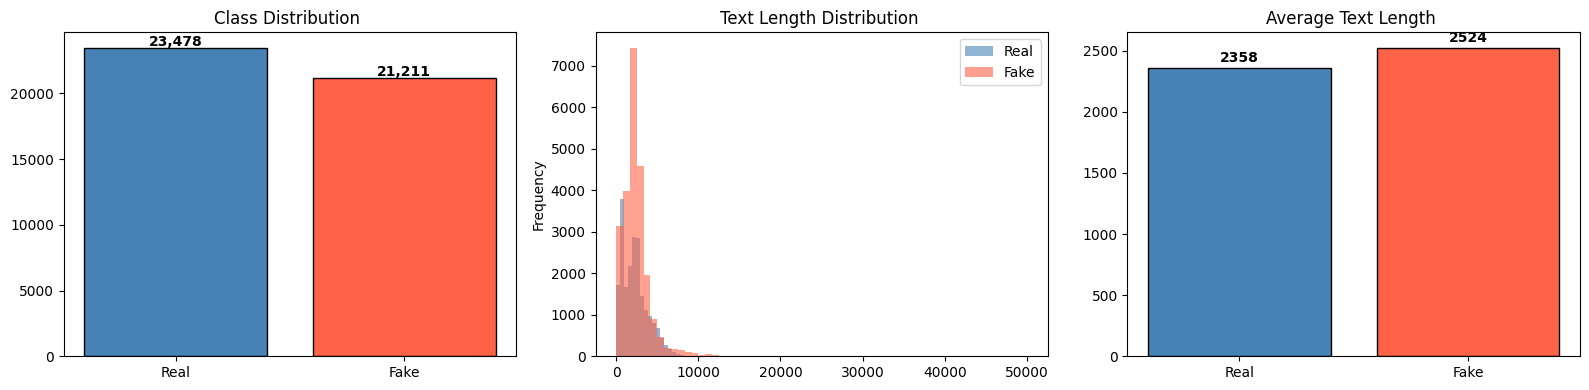

         count    mean     std   min     25%     50%     75%      max
label                                                                
0      21211.0  2358.3  1626.7  29.0   935.0  2201.0  3177.0  29002.0
1      23478.0  2524.0  2428.6   0.0  1460.0  2164.0  2983.0  50060.0


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

counts = df['label'].value_counts()
axes[0].bar(['Real', 'Fake'], counts.values, color=['steelblue','tomato'], edgecolor='black')
axes[0].set_title('Class Distribution ')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+100, f'{v:,}', ha='center', fontweight='bold')

df[df['label']==0]['text_len'].plot(kind='hist', bins=60, ax=axes[1], alpha=0.6, color='steelblue', label='Real')
df[df['label']==1]['text_len'].plot(kind='hist', bins=60, ax=axes[1], alpha=0.6, color='tomato', label='Fake')
axes[1].set_title('Text Length Distribution ')
axes[1].legend()

avg = df.groupby('label')['text_len'].mean()
axes[2].bar(['Real','Fake'], avg.values, color=['steelblue','tomato'], edgecolor='black')
axes[2].set_title('Average Text Length ')
for i, v in enumerate(avg.values):
    axes[2].text(i, v+50, f'{v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(df.groupby('label')['text_len'].describe().round(1))

In [ ]:
X = df['content']
y = df['label']

# 80test 20train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

# TF-IDF
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2), sublinear_tf=True, min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'TF-IDF shape: {X_train_tfidf.shape}')

Train: 35,751 | Test: 8,938
TF-IDF shape: (35751, 50000)


In [ ]:
svd = TruncatedSVD(n_components=300, random_state=42)
X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd  = svd.transform(X_test_tfidf)

print(f'Explained variance (300 components): {svd.explained_variance_ratio_.sum():.2%}')
print(f'Reduced shape: {X_train_svd.shape}')

Explained variance (300 components): 15.80%
Reduced shape: (35751, 300)


Adjusted Rand Index: 0.6928


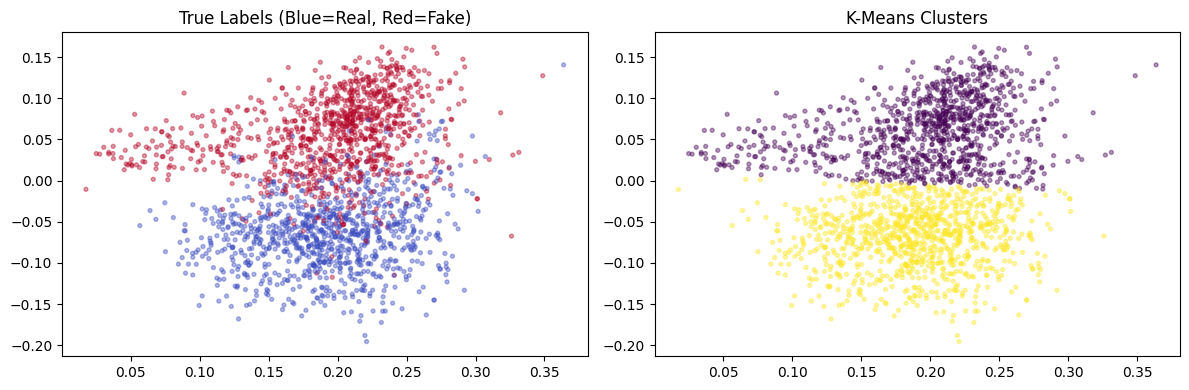

In [ ]:
SAMPLE = 5000
X_cluster = X_train_svd[:SAMPLE]
y_cluster = y_train.values[:SAMPLE]

km = KMeans(n_clusters=2, random_state=42, n_init=10)
km.fit(X_cluster)

ari = adjusted_rand_score(y_cluster, km.labels_)
print(f'Adjusted Rand Index: {ari:.4f}')

svd_2d = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd_2d.fit_transform(X_train_tfidf[:2000])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(X_2d[:,0], X_2d[:,1], c=y_train.values[:2000], cmap='coolwarm', alpha=0.4, s=8)
axes[0].set_title('True Labels (Blue=Real, Red=Fake)')

km2d = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_2d = km2d.fit_predict(X_2d)
axes[1].scatter(X_2d[:,0], X_2d[:,1], c=labels_2d, cmap='viridis', alpha=0.4, s=8)
axes[1].set_title('K-Means Clusters')

plt.tight_layout()
plt.show()

=== MODEL 1: Logistic Regression ===
Accuracy: 0.9922
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      4242
        Fake       0.99      0.99      0.99      4696

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



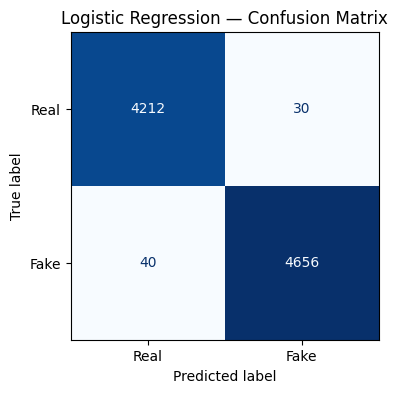

In [ ]:
print('=== MODEL 1: Logistic Regression ===')
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f'Accuracy: {acc_lr:.4f}')
print(classification_report(y_test, y_pred_lr, target_names=['Real','Fake']))

fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr), display_labels=['Real','Fake']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Logistic Regression — Confusion Matrix')
plt.show()

=== MODEL 2: Passive Aggressive Classifier ===
Accuracy: 0.9973
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      4242
        Fake       1.00      1.00      1.00      4696

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



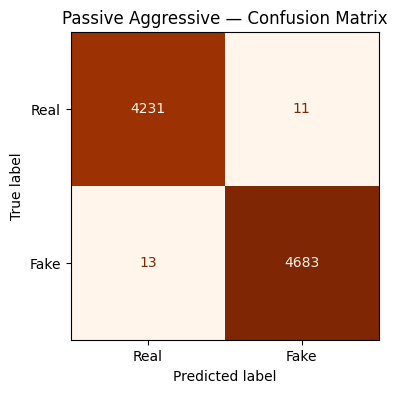

In [ ]:
print('=== MODEL 2: Passive Aggressive Classifier ===')
pac = PassiveAggressiveClassifier(max_iter=1000, random_state=42)
pac.fit(X_train_tfidf, y_train)
y_pred_pac = pac.predict(X_test_tfidf)

acc_pac = accuracy_score(y_test, y_pred_pac)
print(f'Accuracy: {acc_pac:.4f}')
print(classification_report(y_test, y_pred_pac, target_names=['Real','Fake']))

fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_pac), display_labels=['Real','Fake']).plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('Passive Aggressive — Confusion Matrix')
plt.show()

In [ ]:
lr_svd = LogisticRegression(max_iter=1000, random_state=42)
lr_svd.fit(X_train_svd, y_train)
acc_svd = accuracy_score(y_test, lr_svd.predict(X_test_svd))

print(f'LR — Full TF-IDF (50,000 features): {acc_lr:.4f}')
print(f'LR — After SVD   (300 components):  {acc_svd:.4f}')
diff = abs(acc_lr - acc_svd) * 100
winner = 'Full TF-IDF' if acc_lr >= acc_svd else 'SVD'
print(f'\n→ {winner} wins by {diff:.2f}%')

LR — Full TF-IDF (50,000 features): 0.9922
LR — After SVD   (300 components):  0.9879

→ Full TF-IDF wins by 0.43%


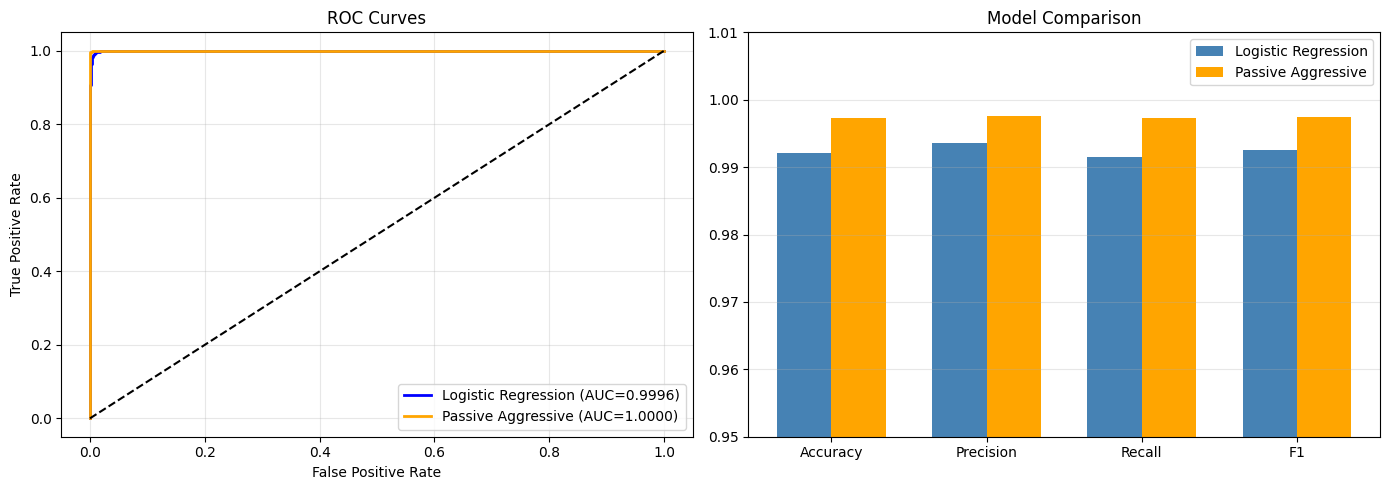


=== FINAL SUMMARY ===
              Model Accuracy F1 Score Precision Recall
Logistic Regression   0.9922   0.9925    0.9936 0.9915
 Passive Aggressive   0.9973   0.9974    0.9977 0.9972


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curves
for model, preds, name, color in [
    (lr,  y_pred_lr,  'Logistic Regression', 'blue'),
    (pac, y_pred_pac, 'Passive Aggressive',  'orange')
]:
    score = model.decision_function(X_test_tfidf)
    fpr, tpr, _ = roc_curve(y_test, score)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc(fpr,tpr):.4f})')

axes[0].plot([0,1],[0,1],'k--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Bar comparison
metrics = ['Accuracy','Precision','Recall','F1']
vals_lr  = [accuracy_score(y_test,y_pred_lr), precision_score(y_test,y_pred_lr),
            recall_score(y_test,y_pred_lr), f1_score(y_test,y_pred_lr)]
vals_pac = [accuracy_score(y_test,y_pred_pac), precision_score(y_test,y_pred_pac),
            recall_score(y_test,y_pred_pac), f1_score(y_test,y_pred_pac)]

x = np.arange(len(metrics))
axes[1].bar(x-0.175, vals_lr,  0.35, label='Logistic Regression', color='steelblue')
axes[1].bar(x+0.175, vals_pac, 0.35, label='Passive Aggressive',  color='orange')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_ylim([0.95, 1.01])
axes[1].set_title('Model Comparison')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('\n=== FINAL SUMMARY ===')
print(pd.DataFrame({
    'Model':     ['Logistic Regression','Passive Aggressive'],
    'Accuracy':  [f'{accuracy_score(y_test,y_pred_lr):.4f}', f'{accuracy_score(y_test,y_pred_pac):.4f}'],
    'F1 Score':  [f'{f1_score(y_test,y_pred_lr):.4f}',       f'{f1_score(y_test,y_pred_pac):.4f}'],
    'Precision': [f'{precision_score(y_test,y_pred_lr):.4f}',f'{precision_score(y_test,y_pred_pac):.4f}'],
    'Recall':    [f'{recall_score(y_test,y_pred_lr):.4f}',   f'{recall_score(y_test,y_pred_pac):.4f}'],
}).to_string(index=False))

In [ ]:
print('Pipeline complete!')
print('All required steps covered:')
print('  Data inspection → Cleaning → EDA → TF-IDF → SVD → Clustering → 2 Models → ROC → Comparison')

Pipeline complete!
All required steps covered:
  Data inspection → Cleaning → EDA → TF-IDF → SVD → Clustering → 2 Models → ROC → Comparison
